In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import RocCurveDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [24]:
# Dataset load (apna path daalo)
df = pd.read_csv('/content/Customertravel - Customertravel.csv')  # Ya upload karke path
# Dataset already loaded hai, bas Target use karo
print("✅ Dataset Perfectly Loaded!")
print("Shape:", df.shape)  # (954, 7)
print("Columns:", df.columns.tolist())
print("\nTarget distribution (Churn):")
print(df['Target'].value_counts())  # 0 (No Churn), 1 (Churn)

# Churn % calculate
churn_rate = df['Target'].mean() * 100
print(f"Churn Rate: {churn_rate:.1f}%")

✅ Dataset Perfectly Loaded!
Shape: (954, 7)
Columns: ['Age', 'FrequentFlyer', 'AnnualIncomeClass', 'ServicesOpted', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot', 'Target']

Target distribution (Churn):
Target
0    730
1    224
Name: count, dtype: int64
Churn Rate: 23.5%


In [ ]:
# Categorical columns ko numbers banao
le = LabelEncoder()
categorical_cols = ['FrequentFlyer', 'AnnualIncomeClass', 'AccountSyncedToSocialMedia', 'BookedHotelOrNot']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    print(f"✅ Encoded {col}: {df[col].unique()}")
print("\n📊 Data after encoding:")
print(df.head())
print("\n✅ Encoding COMPLETE!")

✅ Encoded FrequentFlyer: [0 2 1]
✅ Encoded AnnualIncomeClass: [2 1 0]
✅ Encoded AccountSyncedToSocialMedia: [0 1]
✅ Encoded BookedHotelOrNot: [1 0]

📊 Data after encoding:
   Age  FrequentFlyer  AnnualIncomeClass  ServicesOpted  \
0   34              0                  2              6   
1   34              2                  1              5   
2   37              0                  2              3   
3   30              0                  2              2   
4   30              0                  1              1   

   AccountSyncedToSocialMedia  BookedHotelOrNot  Target  
0                           0                 1       0  
1                           1                 0       1  
2                           1                 0       0  
3                           0                 0       0  
4                           0                 0       0  

✅ Encoding COMPLETE!


In [ ]:
# X = features, y = target (churn)
X = df.drop('Target', axis=1)
y = df['Target']

print("✅ Features (X):", X.shape)  # (954, 6)
print("Target (y):", y.shape)
print("\nFeatures preview:")
print(X.head())

✅ Features (X): (954, 6)
Target (y): (954,)

Features preview:
   Age  FrequentFlyer  AnnualIncomeClass  ServicesOpted  \
0   34              0                  2              6   
1   34              2                  1              5   
2   37              0                  2              3   
3   30              0                  2              2   
4   30              0                  1              1   

   AccountSyncedToSocialMedia  BookedHotelOrNot  
0                           0                 1  
1                           1                 0  
2                           1                 0  
3                           0                 0  
4                           0                 0  


In [28]:
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("✅ Training data:", X_train.shape)
print("Test data:", X_test.shape)

✅ Training data: (763, 6)
Test data: (191, 6)


In [29]:
# Model train karo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test pe predict
y_pred = rf_model.predict(X_test)
print("✅ Model trained successfully!")

✅ Model trained successfully!


In [30]:
# Accuracy dekho
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 ACCURACY: {accuracy:.3f} ({accuracy*100:.1f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Detailed Report
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

🎯 ACCURACY: 0.890 (89.0%)

Confusion Matrix:
[[139   7]
 [ 14  31]]

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       146
           1       0.82      0.69      0.75        45

    accuracy                           0.89       191
   macro avg       0.86      0.82      0.84       191
weighted avg       0.89      0.89      0.89       191



In [31]:
# Konse features important hain?
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("🔥 TOP FEATURES:")
print(feature_df)

🔥 TOP FEATURES:
                      Feature  Importance
0                         Age    0.299980
3               ServicesOpted    0.251562
1               FrequentFlyer    0.165540
2           AnnualIncomeClass    0.138526
4  AccountSyncedToSocialMedia    0.098386
5            BookedHotelOrNot    0.046006


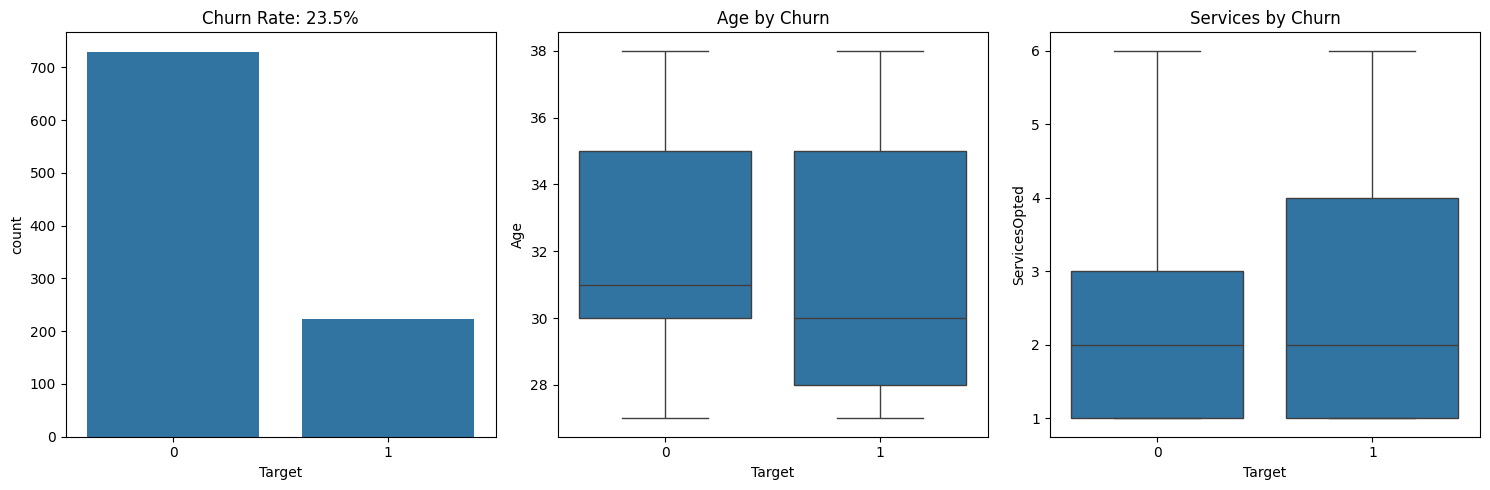

In [32]:
plt.figure(figsize=(15, 5))

# Chart 1: Churn Distribution
plt.subplot(1, 3, 1)
sns.countplot(x='Target', data=df)
plt.title('Churn Rate: 23.5%')

# Chart 2: Age vs Churn
plt.subplot(1, 3, 2)
sns.boxplot(x='Target', y='Age', data=df)
plt.title('Age by Churn')

# Chart 3: Services vs Churn
plt.subplot(1, 3, 3)
sns.boxplot(x='Target', y='ServicesOpted', data=df)
plt.title('Services by Churn')

plt.tight_layout()
plt.show()

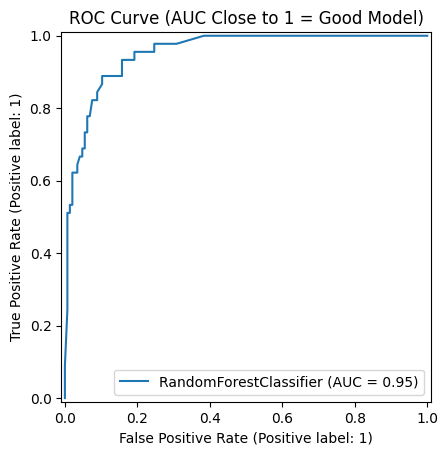

In [33]:
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title('ROC Curve (AUC Close to 1 = Good Model)')
plt.show()

In [34]:
joblib.dump(rf_model, 'model.pkl')
print("✅ Model saved for deployment!")

✅ Model saved for deployment!


In [38]:
# app.py CREATE
app_code = '''import streamlit as st
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

model = joblib.load('model.pkl')
st.title("✈️ Travel Churn Predictor")

age = st.slider("Age", 27, 38, 31)
frequent = st.selectbox("Frequent Flyer", ["No", "Yes"])
income = st.selectbox("Income", ["Low Income", "Middle Income"])
services = st.slider("Services", 1, 6, 2)
social = st.selectbox("Social Media", ["No", "Yes"])
hotel = st.selectbox("Hotel", ["No", "Yes"])

if st.button("🔮 Predict"):
    input_data = pd.DataFrame({
        'Age': [age], 'FrequentFlyer': [frequent],
        'AnnualIncomeClass': [income], 'ServicesOpted': [services],
        'AccountSyncedToSocialMedia': [social], 'BookedHotelOrNot': [hotel]
    })

    le = LabelEncoder()
    cat_cols = ['FrequentFlyer','AnnualIncomeClass','AccountSyncedToSocialMedia','BookedHotelOrNot']
    for col in cat_cols:
        input_data[col] = le.fit_transform(input_data[col])

    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]
    st.success(f"Result: {'🛑 CHURN' if pred==1 else '✅ STAY'} ({prob:.0%})")
'''

with open('app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py BAN GAYA!")

✅ app.py BAN GAYA!


In [36]:
with open('requirements.txt', 'w') as f:
    f.write('''streamlit
pandas
scikit-learn
joblib
numpy''')
print("✅ requirements.txt BAN GAYA!")

✅ requirements.txt BAN GAYA!


In [39]:
from google.colab import files
files.download('model.pkl')
files.download('app.py')
files.download('requirements.txt')
print("✅ 3 FILES DOWNLOAD HO GAYI!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 3 FILES DOWNLOAD HO GAYI!
